# PFC — selectivity structure and population geometry

Ports Posani, Wang, Muscinelli, Paninski & Fusi (Nature 2026), *Rarely categorical,
highly separable representations along the cortical hierarchy*, to the ABCD maze.

Method write-up, including everything that does **not** port directly:
[`SELECTIVITY_GEOMETRY.md`](SELECTIVITY_GEOMETRY.md).

Order matters. The synthetic gate runs first and gates everything after it.

In [1]:
import pickle, sys
from importlib import reload
import numpy as np, pandas as pd
import glm_analysis_v2 as glm
import selectivity_geometry as sg
glm.apply_gridmaze_style()

REGION   = 'PFC'
GLM_DIR  = '../glm_outputs/PFC'
SAVE_DIR = '../glm_outputs/PFC_selectivity_geometry'
SECTION  = 'distance_gp'

DATA = '../data'
mouse_recdays = list(np.load(f'{DATA}/MetaData/combined_ABCDonly_days.npy'))
# compute_norm=True is required: the conditions-space analyses read Neurons_norm.
data_dic = glm.build_data_dic_from_pfc(DATA, mouse_recdays, verbose=False, compute_norm=True)
print(REGION, len(mouse_recdays), 'recdays')

PFC 25 recdays


## 1. The gate

Synthetics through the real functions, unmodified. The critical row is **`uneven`**:
an elongated but *unclustered* cloud must read non-categorical. If it does not, the
null is matching total variance rather than the covariance, and every number below
is measuring anisotropy and calling it clustering.

`collinear` is the second gate — maximal M_IC with low separability, which is what
keeps dimensionality and separability from collapsing into one quantity.

In [2]:
reload(sg)
gate = sg.run_synthetic_controls()
assert gate['pass'].all(), 'GATE FAILED — stop here, nothing below is interpretable'

  family                        kind       metric   value                             aux expect  pass
   alpha                   isotropic silhouette_z -0.6400                k=19, a-div=6.96     ns  True
   alpha                      uneven silhouette_z -0.0900                 k=3, a-div=1.53     ns  True
   alpha                 categorical silhouette_z 67.4400                 k=4, a-div=2.57    sig  True
   alpha                        junk silhouette_z 19.8800                 k=3, a-div=1.53    sig  True
   alpha             uneven(rotated) silhouette_z -0.0900 null must be rotation-invariant     ns  True
geometry                     highdim separability  1.0000              PR=13.27, AD=1.000   high  True
geometry                      lowdim separability  0.5170               PR=2.07, AD=0.573    mid  True
geometry                   collinear separability  0.3000               PR=1.02, AD=0.552    low  True
geometry                   collinear         M_IC 16.0000    high M_IC + 

## 2. Build alpha

`alpha[n,v] = sign_v * RMS(beta_n[cols_v]) / sd_n`. See §2 of the doc for why RMS
(blocks differ in width) and why the `/sd_n` is not optional (this GLM fits raw
spike counts, so betas carry firing rate).

`neuron_scales` is produced by `run_glm_analysis(..., return_scales=True)`. If the
section predates that, backfill it with `scales_only=True` — seconds, not hours:

```python
*_, scales = glm.run_glm_analysis(recdays, data_dic, return_scales=True,
                                  scales_only=True, **SAME_KWARGS_AS_THE_FIT)
```

In [3]:
reload(sg)
GP_DIST = ['place', 'goal_progress', 'speed', 'acceleration',
           'time_since_reward', 'time_to_reward',
           'distance_since_reward', 'distance_to_reward', 'goal_progress_distance']
cfg = sg.SelectivityConfig(regressors=tuple(GP_DIST))

L = lambda k: pickle.load(open(f'{GLM_DIR}/{SECTION}__{k}.pkl', 'rb'))
glm_results, perm_results = L('glm_results'), L('permutation_results')
cpd_results, neuron_scales = L('cpd_results'), L('neuron_scales')

A, meta = sg.build_alpha_matrix(glm_results, neuron_scales, cpd_results, cfg)
names = meta.attrs['alpha_names']
K = meta['keep'].values
print(f'alpha {A.shape}; kept {K.sum()}/{len(meta)} '
      f'({meta["recday"].nunique()} recdays, {meta["mouse"].nunique()} mice)')

alpha (1252, 9); kept 630/1252 (25 recdays, 7 mice)


In [4]:
# Consistency test against already-validated output: alpha's sign and tuned_dict's
# +1/-1 both come from _beta_direction, so they must agree exactly wherever
# tuned_dict is significant. Anything below 1.0 means the regressor list /
# gp_n_bins / parameterization here does not describe the fitted section.
tuned = glm.compute_tuning_arrays(glm_results, perm_results, regressors_to_include=GP_DIST)
n_ok, n_tot, frac = sg.check_alpha_against_tuning(A, meta, tuned, cfg)
print(f'sign agreement with tuned_dict: {n_ok}/{n_tot} = {frac:.4f}')
assert frac == 1.0

ab03_01092023_02092023: tuning array shape = (63, 9)
ab03_05092023_06092023: tuning array shape = (64, 9)
ab03_29082023_30082023: tuning array shape = (70, 9)
ah03_12082021_13082021: tuning array shape = (16, 9)
ah03_18082021_19082021: tuning array shape = (15, 9)
ah04_01122021_02122021: tuning array shape = (117, 9)
ah04_05122021_06122021: tuning array shape = (114, 9)
ah04_07122021_08122021: tuning array shape = (81, 9)
ah04_09122021_10122021: tuning array shape = (99, 9)
ah04_14122021_16122021: tuning array shape = (70, 9)
ah07_01092023_02092023: tuning array shape = (97, 9)
ah07_27082023_28082023: tuning array shape = (80, 9)
ah07_29082023_30082023: tuning array shape = (72, 9)
me08_06092021_09092021: tuning array shape = (23, 9)
me08_10092021_11092021: tuning array shape = (32, 9)
me08_12092021_13092021: tuning array shape = (23, 9)
me10_09122021_10122021: tuning array shape = (28, 9)
me10_14122021_15122021: tuning array shape = (20, 9)
me10_17122021_19122021: tuning array shape =

## 3. Is the representation categorical?

k-means sweep over k = 3..20, keep the k maximising the silhouette, compare against
100 draws from a **mean- and covariance-matched multivariate Gaussian** pushed
through the identical sweep.

Always show the null panel next to the data panel. A sorted selectivity matrix looks
convincingly blocked whenever a few variables dominate — in the paper, VISp
(categorical) and ACAd (not) look equally structured by eye.

z = 2.79 | k = 3 | ss_data = 0.2565 | ss_null = 0.2299 | n = 630 (dropped by purity guard: 0)
alpha-diversity = 2.29 (max 9)
CATEGORICAL


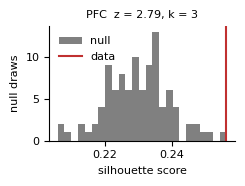

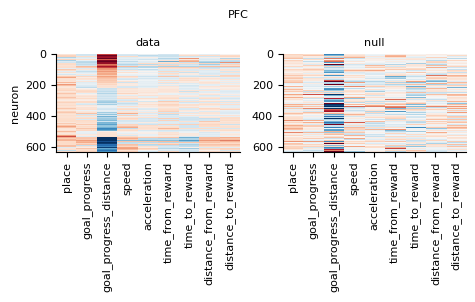

In [5]:
reload(sg)
res = sg.cluster_quality(A[K], meta['recday'].values[K], cfg, n_jobs=4)
print(f"z = {res['z']:.2f} | k = {res['k']} | ss_data = {res['ss_data']:.4f} | "
      f"ss_null = {np.mean(res['ss_null']):.4f} | n = {res['n_used']} "
      f"(dropped by purity guard: {res['n_dropped']})")
print(f"alpha-diversity = {sg.alpha_diversity(A[K], cfg):.2f} (max {len(names)})")
print('CATEGORICAL' if res['z'] > cfg.z_significant else 'not categorical')

rng = np.random.default_rng(0)
null_A = sg._sample_null(A[K][res['keep']], 'gaussian_cov', rng)
sg.plot_silhouette_null(res, region=REGION)
sg.plot_selectivity_matrix(A[K], res, names, region=REGION, null_A=null_A);

## 4. Audit: does the verdict depend on the null?

Three nulls, same data. Only `gaussian_cov` is correct — it is unimodal *and*
covariance-matched, so a high silhouette can only come from multimodality.
`gaussian_iso` matches total variance but not its shape, so any elongated cloud
beats it.

,null_kind,z,ss_data,ss_null_mean,k,n_used,categorical
0,gaussian_cov,2.791,0.256,0.230,3,630,True
1,gaussian_iso,79.950,0.256,0.090,3,630,True
2,shuffle_cols,2.909,0.256,0.229,3,630,True


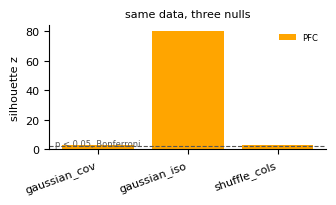

In [6]:
reload(sg)
null_audit = sg.audit_null_kind(A[K], meta['recday'].values[K], cfg, n_jobs=4)
display(null_audit.round(3))
sg.plot_null_audit(null_audit.assign(region=REGION), z_significant=cfg.z_significant);

## 5. Audit: does the verdict depend on the inclusion threshold?

Posani's Methods warning, made checkable. Keep every neuron and a spike of
near-zero-selectivity cells appears that no unimodal null can reproduce, so the
region reads categorical for reasons unrelated to functional structure. Cut too
hard and the centre of the distribution is depleted, producing the same artefact
from the other side.

**If z crosses the significance line inside this sweep, the verdict is
threshold-dependent and should be reported as such, not as a result.**

,min_r2_full,n,z,k,alpha_diversity,categorical
0,0.000,1108,5.901,3,2.453,True
1,0.005,1091,5.723,3,2.426,True
2,0.010,943,5.036,3,2.446,True
3,0.020,630,2.791,3,2.286,True
4,0.050,236,3.974,3,1.889,True
5,0.100,69,2.357,3,1.607,True


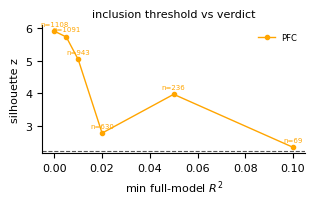

In [7]:
reload(sg)
incl_audit = sg.audit_inclusion_threshold(A, meta, cfg, n_jobs=4)
display(incl_audit.round(3))
sg.plot_inclusion_audit(incl_audit.assign(region=REGION), z_significant=cfg.z_significant);

,dropped,ss,delta_ss,z,delta_z,k
0,(none),0.256,0.000,2.628,0.000,3
1,place,0.265,-0.009,3.366,0.737,3
2,goal_progress,0.275,-0.019,4.127,1.499,3
3,goal_progress_distance,0.185,0.072,7.318,4.690,3
4,speed,0.277,-0.021,3.582,0.954,3
5,acceleration,0.261,-0.005,2.630,0.002,3
6,time_from_reward,0.279,-0.023,3.666,1.038,3
7,time_to_reward,0.271,-0.015,3.595,0.966,3
8,distance_from_reward,0.267,-0.010,2.912,0.283,3
9,distance_to_reward,0.266,-0.010,2.849,0.220,3


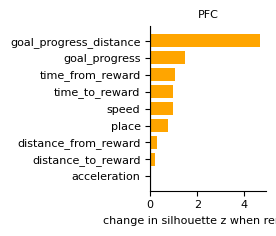

In [8]:
reload(sg)
m2 = meta[K].copy(); m2.attrs['alpha_names'] = names
varcon = sg.variable_contribution(A[K], m2, sg.replace(cfg, n_null=30),
                                  m2['recday'].values, n_jobs=4)
display(varcon.round(3))
# Read delta_z, not delta_ss: silhouette depends on dimensionality, and dropping a
# variable changes it. Positive delta_z = the verdict is STRONGER without that
# variable, i.e. it was masking clustering rather than creating it.
sg.plot_variable_contribution(varcon, region=REGION);

In [9]:
glm.save_section('clustering', SAVE_DIR,
                 results={'alpha': A, 'meta': meta, 'cluster_result': res,
                          'null_audit': null_audit, 'inclusion_audit': incl_audit,
                          'variable_contribution': varcon},
                 fig_names=['silhouette_null', 'selectivity_matrix', 'null_audit',
                            'inclusion_audit', 'variable_contribution'])

save_section('clustering'): wrote 6 file(s) to ../glm_outputs/PFC_selectivity_geometry


['../glm_outputs/PFC_selectivity_geometry/clustering__alpha.pkl',
 '../glm_outputs/PFC_selectivity_geometry/clustering__meta.pkl',
 '../glm_outputs/PFC_selectivity_geometry/clustering__cluster_result.pkl',
 '../glm_outputs/PFC_selectivity_geometry/clustering__null_audit.pkl',
 '../glm_outputs/PFC_selectivity_geometry/clustering__inclusion_audit.pkl',
 '../glm_outputs/PFC_selectivity_geometry/clustering__variable_contribution.pkl']

## 6. Conditions space

Four condition definitions (§4 of the doc). `state_task` is the one the CCGP bridge
uses, because it is built from exactly the vectors `ccgp_state_pairs` decodes —
asserted below by `check_matches_ccgp`.

**Caveat that travels with every number in this section:** `Neurons_norm` is
phase-warped, so time and progress are conjoined by construction here.
Dissociating them is the job of `time_vs_progress_dissociation.py`.

In [10]:
reload(sg)
chk = sg.check_matches_ccgp(data_dic, mouse_recdays[0])
print('reproduces ccgp_state_pairs sampler:', chk)
assert chk['shapes_match'] and chk['max_abs_diff'] == 0.0

for name, spec in sg.CONDITION_SPECS.items():
    t = sg.build_condition_table(data_dic, mouse_recdays[0], spec, cfg)
    print(f'{name:18s}', 'skipped' if t is None else
          f"F={t['F'].shape} M={len(np.unique(t['cond']))} n_tasks={t['n_tasks']}")

reproduces ccgp_state_pairs sampler: {'shape_ours': (732, 63), 'shape_theirs': (732, 63), 'shapes_match': True, 'max_abs_diff': 0.0}
state_prog_speed   F=(1464, 63) M=16 n_tasks=6
state_task         F=(732, 63) M=24 n_tasks=6
state_prog_task    F=(1464, 63) M=48 n_tasks=6
state_tower        F=(732, 63) M=19 n_tasks=6


,n_neurons_avail,M,m_ic,pr,pr_ic,sep_all,ad_all,sep_ic,ad_ic
spec,,,,,,,,,
state_prog_speed,72.0,16.0,5.0,4.084,2.402,0.98,0.618,1.00,0.684
state_prog_task,72.0,48.0,15.0,7.436,5.043,0.98,0.590,1.00,0.641
state_task,72.0,24.0,9.0,7.518,4.523,0.90,0.598,0.99,0.668
state_tower,72.0,21.0,7.0,6.921,4.090,0.92,0.612,0.99,0.677


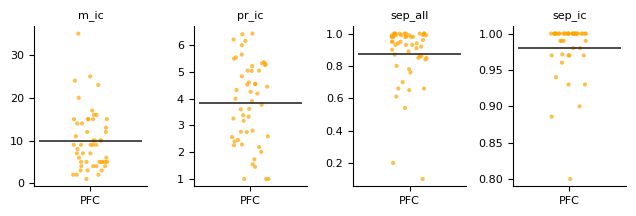

In [11]:
reload(sg)
# n_sub_neurons is the N-matching floor: M_IC, PR and separability all grow with
# population size, and the two regions differ systematically in yield.
gcfg = sg.replace(cfg, n_sub_neurons=40, n_sub_reps=20, n_dichotomies=100)

geo = pd.concat([sg.run_geometry_batch(data_dic, spec, mouse_recdays, gcfg,
                                       region=REGION, verbose=False)
                 for spec in sg.CONDITION_SPECS.values()], ignore_index=True)
display(geo.groupby('spec')[['n_neurons_avail', 'M', 'm_ic', 'pr', 'pr_ic',
                             'sep_all', 'ad_all', 'sep_ic', 'ad_ic']].median().round(3))
sg.plot_geometry_summary(geo.assign(region=REGION));

## 7. N-sensitivity

Every cross-region claim has to carry this curve. The annotations under each point
are the number of surviving recdays — a metric quoted at a single N, without the
recday count, is not interpretable.

  N=20: 20 recdays
  N=30: 14 recdays
  N=40: 13 recdays
  N=60: 11 recdays
  N=80: 6 recdays


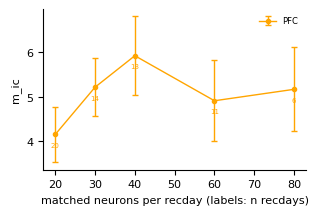

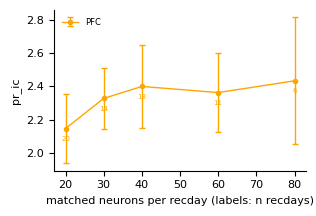

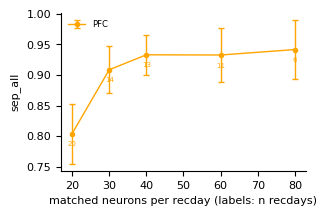

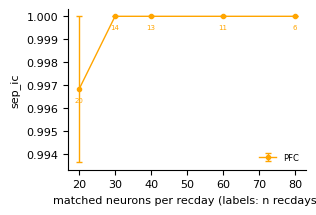

In [12]:
reload(sg)
nsens = sg.n_sensitivity(data_dic, sg.CONDITION_SPECS['state_prog_speed'],
                         mouse_recdays, gcfg, n_grid=(20, 30, 40, 60, 80), region=REGION)
for m in ['m_ic', 'pr_ic', 'sep_all', 'sep_ic']:
    sg.plot_n_sensitivity(nsens, metric=m)

## 8. Separability vs CCGP

The paper states that maximal separability does not imply an absence of structure,
and that a representation can be abstract in the Bernardi (2020) sense *and* shatter
every dichotomy — but never measures both. Both are measured here on identical
population vectors.

,recday,n_neurons_used,m_ic,pr,sep_all,sep_ic,ccgp_mean
0,ab03_01092023_02092023,40,16,6.153,0.94,1.000,0.466
1,ab03_05092023_06092023,40,6,7.522,0.70,1.000,0.446
2,ab03_29082023_30082023,40,8,7.882,0.86,0.971,0.426
3,ah04_01122021_02122021,40,5,8.271,0.66,1.000,0.498
4,ah04_05122021_06122021,40,5,9.059,0.90,1.000,0.484
5,ah04_07122021_08122021,40,2,10.073,0.10,NaN,0.456
6,ah04_09122021_10122021,40,3,7.236,0.66,NaN,0.455
7,ah04_14122021_16122021,40,20,7.042,0.99,0.990,0.510
8,ah07_01092023_02092023,40,10,6.776,0.87,0.940,0.459
9,ah07_27082023_28082023,40,15,7.727,0.98,0.960,0.495


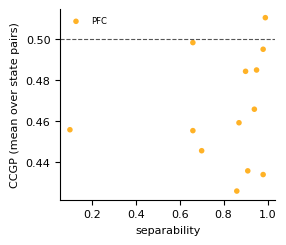

In [13]:
reload(sg)
join = sg.run_ccgp_separability_join(data_dic, mouse_recdays, gcfg,
                                     region=REGION, verbose=False)
display(join[['recday', 'n_neurons_used', 'm_ic', 'pr', 'sep_all', 'sep_ic',
              'ccgp_mean']].round(3))
sg.plot_separability_vs_ccgp(join);

In [14]:
glm.save_section('geometry', SAVE_DIR,
                 results={'geometry': geo, 'n_sensitivity': nsens, 'ccgp_join': join},
                 fig_names=['geometry_summary', 'nsens_mic', 'nsens_pric',
                            'nsens_sep_all', 'nsens_sep_ic', 'sep_vs_ccgp'])

save_section('geometry'): wrote 3 file(s) to ../glm_outputs/PFC_selectivity_geometry


['../glm_outputs/PFC_selectivity_geometry/geometry__geometry.pkl',
 '../glm_outputs/PFC_selectivity_geometry/geometry__n_sensitivity.pkl',
 '../glm_outputs/PFC_selectivity_geometry/geometry__ccgp_join.pkl']

## Reading these figures

- **Only the z-score is interpretable**, never the raw silhouette. Silhouette grows
  as dimensionality falls, which is what the matched null exists to remove.
- **Two regions is a contrast, not a gradient.** The paper's headline is a trend
  across 43 areas; there is no hierarchy axis to regress against here.
- **Check §5 before quoting §3.** If the verdict moves across the inclusion sweep,
  the honest report is "threshold-dependent", not a verdict.
- **Every §6-8 number inherits the phase warp** and the N-matching floor.